# Benchmark Analysis: Aggregate Results

This notebook analyzes the benchmark output in `results/all_benchmarks_aggregate.json`.

It focuses on:
- Overall benchmark health (success rate, runtime)
- Per-agent and per-benchmark performance
- Error diagnostics for failed runs
- Detection quality (false positives and missed anomalies)

In [8]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

In [9]:
candidate_paths = [
    Path("results/all_benchmarks_aggregate.json"),
    Path("../../../../results/all_benchmarks_aggregate.json"),
    Path("/home/isaacp/repos/directlabs/JFN-Groundtruth-Simulator/results/all_benchmarks_aggregate.json"),
]

json_path = next((p.resolve() for p in candidate_paths if p.exists()), None)
if json_path is None:
    raise FileNotFoundError("Could not locate results/all_benchmarks_aggregate.json")

with json_path.open("r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Loaded: {json_path}")
print(f"Started at:  {data.get('started_at')}")
print(f"Finished at: {data.get('finished_at')}")
print(f"Total runs:  {data.get('summary', {}).get('total_runs')}")

Loaded: /home/isaacp/repos/direct/JFN-Groundtruth-Tools/actint/src/actint/benchmarking/results/all_benchmarks_aggregate.json
Started at:  2026-04-06T21:00:08.982243+00:00
Finished at: 2026-04-06T22:08:53.368612+00:00
Total runs:  4


## Normalize Run-Level Data

Convert nested result objects into a flat DataFrame and derive quality metrics per run:
- success/failure
- detected expected anomalies
- false positives
- misses
- precision, recall, and F1

In [10]:
runs = pd.json_normalize(data.get("results", []), sep=".")
runs.keys()


Index(['agent', 'model_id', 'benchmark_id', 'run_index', 'prompt', 'duration_sec', 'agent_output', 'runtime_inputs.expected_loitering_mmsis',
       'validation.success', 'validation.expected.expected_loitering_mmsis', 'validation.expected.expected_count', 'validation.predicted.reported_mmsis',
       'validation.predicted.reported_count', 'validation.metrics.minimum_detected', 'validation.metrics.detected_expected_count',
       'validation.metrics.detected_expected_mmsis', 'validation.metrics.missed_expected_mmsis', 'validation.metrics.false_positive_mmsis'],
      dtype='str')

In [11]:
runs = pd.json_normalize(data.get("results", []), sep=".")

if runs.empty:
    raise ValueError("No runs found in the aggregate JSON")

runs["success"] = runs["validation.success"].fillna(False).astype(bool)
runs["duration_sec"] = pd.to_numeric(runs["duration_sec"], errors="coerce")
runs["expected_count"] = pd.to_numeric(runs["validation.expected.expected_count"], errors="coerce").fillna(0).astype(int)
runs["detected_expected_count"] = pd.to_numeric(runs["validation.metrics.detected_expected_count"], errors="coerce").fillna(0).astype(int)

runs["false_positive_mmsis"] = runs["validation.metrics.false_positive_mmsis"].apply(lambda x: x if isinstance(x, list) else [])
runs["missed_expected_mmsis"] = runs["validation.metrics.missed_expected_mmsis"].apply(lambda x: x if isinstance(x, list) else [])

runs["false_positive_count"] = runs["false_positive_mmsis"].apply(len)
runs["missed_count"] = runs["missed_expected_mmsis"].apply(len)

predicted_total = runs["detected_expected_count"] + runs["false_positive_count"]
runs["precision"] = np.where(predicted_total > 0, runs["detected_expected_count"] / predicted_total, np.nan)
runs["recall"] = np.where(runs["expected_count"] > 0, runs["detected_expected_count"] / runs["expected_count"], np.nan)
runs["f1"] = np.where(
    (runs["precision"] + runs["recall"]) > 0,
    2 * runs["precision"] * runs["recall"] / (runs["precision"] + runs["recall"]),
    np.nan,
)

cols = [
    "agent",
    "model_id",
    "benchmark_id",
    "run_index",
    "success",
    "duration_sec",
    "expected_count",
    "detected_expected_count",
    "false_positive_count",
    "missed_count",
    "precision",
    "recall",
    "f1",
]

runs[cols].sort_values(["benchmark_id", "agent", "run_index"]).reset_index(drop=True)

,agent,model_id,benchmark_id,run_index,success,duration_sec,expected_count,detected_expected_count,false_positive_count,missed_count,precision,recall,f1
0,Qwen/Qwen3.5-27B,Qwen/Qwen3.5-27B,loitering_detection_injected,0,True,139.106573,10,10,0,0,1.0,1.0,1.0
1,Qwen/Qwen3.5-35B-A3B,Qwen/Qwen3.5-35B-A3B,loitering_detection_injected,0,True,183.029689,10,10,0,0,1.0,1.0,1.0
2,qwen2_7b_instruct,Qwen/Qwen2-7B-Instruct,loitering_detection_injected,0,False,14.237591,10,0,0,10,NaN,0.0,NaN
3,qwen35_9b,Qwen/Qwen3.5-9B,loitering_detection_injected,0,True,109.407593,10,10,0,0,1.0,1.0,1.0


## Top-Level Summary

Compare values from the JSON summary block with metrics recomputed from run-level data.

In [12]:
json_summary = data.get("summary", {})

recomputed = {
    "total_runs": int(len(runs)),
    "successful_runs": int(runs["success"].sum()),
    "success_rate": float(runs["success"].mean()),
    "average_duration_sec": float(runs["duration_sec"].mean()),
}

comparison = pd.DataFrame(
    {
        "from_json": {
            "total_runs": json_summary.get("total_runs"),
            "successful_runs": json_summary.get("successful_runs"),
            "success_rate": json_summary.get("success_rate"),
            "average_duration_sec": json_summary.get("average_duration_sec"),
        },
        "recomputed": recomputed,
    }
)
comparison

,from_json,recomputed
total_runs,4.000000,4.000000
successful_runs,3.000000,3.000000
success_rate,0.750000,0.750000
average_duration_sec,111.445362,111.445362


## Agent Performance

Aggregate by agent/model to inspect speed and detection quality.

In [13]:
agent_perf = (
    runs.groupby(["agent", "model_id"], dropna=False)
    .agg(
        runs=("agent", "size"),
        success_rate=("success", "mean"),
        avg_duration_sec=("duration_sec", "mean"),
        avg_precision=("precision", "mean"),
        avg_recall=("recall", "mean"),
        avg_f1=("f1", "mean"),
        avg_false_positives=("false_positive_count", "mean"),
        avg_missed=("missed_count", "mean"),
    )
    .sort_values(["success_rate", "avg_f1", "avg_duration_sec"], ascending=[False, False, True])
)

agent_perf

,,runs,success_rate,avg_duration_sec,avg_precision,avg_recall,avg_f1,avg_false_positives,avg_missed
agent,model_id,,,,,,,,
qwen35_9b,Qwen/Qwen3.5-9B,1,1.0,109.407593,1.0,1.0,1.0,0.0,0.0
Qwen/Qwen3.5-27B,Qwen/Qwen3.5-27B,1,1.0,139.106573,1.0,1.0,1.0,0.0,0.0
Qwen/Qwen3.5-35B-A3B,Qwen/Qwen3.5-35B-A3B,1,1.0,183.029689,1.0,1.0,1.0,0.0,0.0
qwen2_7b_instruct,Qwen/Qwen2-7B-Instruct,1,0.0,14.237591,NaN,0.0,NaN,0.0,10.0


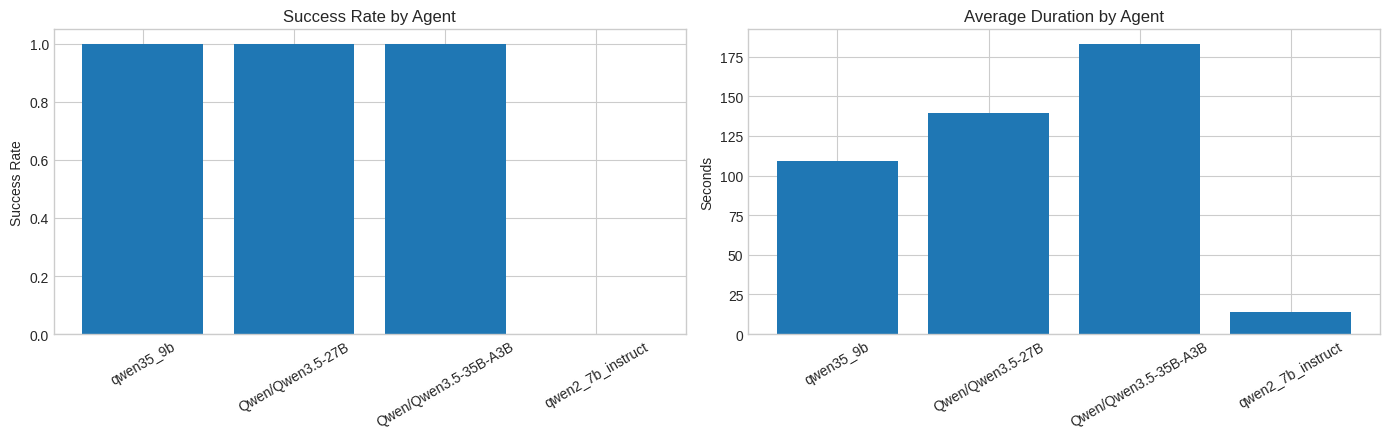

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

agent_plot = agent_perf.reset_index()
axes[0].bar(agent_plot["agent"], agent_plot["success_rate"])
axes[0].set_title("Success Rate by Agent")
axes[0].set_ylabel("Success Rate")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(agent_plot["agent"], agent_plot["avg_duration_sec"])
axes[1].set_title("Average Duration by Agent")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Benchmark-Level View

Compare benchmark tasks on reliability and quality.

In [15]:
benchmark_perf = (
    runs.groupby("benchmark_id", dropna=False)
    .agg(
        runs=("benchmark_id", "size"),
        success_rate=("success", "mean"),
        avg_duration_sec=("duration_sec", "mean"),
        avg_precision=("precision", "mean"),
        avg_recall=("recall", "mean"),
        avg_f1=("f1", "mean"),
        avg_false_positives=("false_positive_count", "mean"),
        avg_missed=("missed_count", "mean"),
    )
    .sort_values("success_rate", ascending=False)
)

benchmark_perf

,runs,success_rate,avg_duration_sec,avg_precision,avg_recall,avg_f1,avg_false_positives,avg_missed
benchmark_id,,,,,,,,
loitering_detection_injected,4,0.75,111.445362,1.0,0.75,1.0,0.0,2.5


## Failed Runs and Error Diagnostics

Inspect failed runs to quickly identify systematic issues (tooling, schema assumptions, model formatting).

,agent,benchmark_id,false_positive_events,missed_events
0,qwen2_7b_instruct,loitering_detection_injected,0.0,10


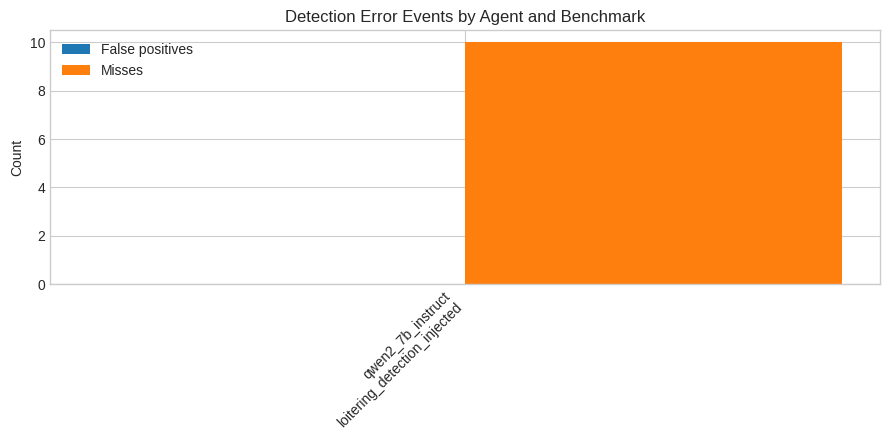

In [17]:
# MMSI-level false positives and misses by agent
fp_long = runs[["agent", "benchmark_id", "false_positive_mmsis"]].explode("false_positive_mmsis").dropna(subset=["false_positive_mmsis"])
miss_long = runs[["agent", "benchmark_id", "missed_expected_mmsis"]].explode("missed_expected_mmsis").dropna(subset=["missed_expected_mmsis"])

fp_counts = fp_long.groupby(["agent", "benchmark_id"]).size().rename("false_positive_events").reset_index()
miss_counts = miss_long.groupby(["agent", "benchmark_id"]).size().rename("missed_events").reset_index()

quality_events = (
    fp_counts.merge(miss_counts, on=["agent", "benchmark_id"], how="outer")
    .fillna(0)
    .sort_values(["benchmark_id", "agent"])
)

if quality_events.empty:
    print("No false-positive or missed-event details found.")
else:
    display(quality_events)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    width = 0.38
    x = np.arange(len(quality_events))

    ax.bar(x - width / 2, quality_events["false_positive_events"], width=width, label="False positives")
    ax.bar(x + width / 2, quality_events["missed_events"], width=width, label="Misses")

    labels = [f"{a}\n{b}" for a, b in zip(quality_events["agent"], quality_events["benchmark_id"])]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Count")
    ax.set_title("Detection Error Events by Agent and Benchmark")
    ax.legend()
    plt.tight_layout()
    plt.show()